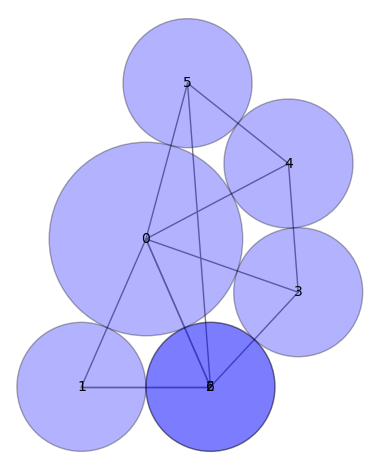

In [5]:
import numpy as np

def solve_intersection(p1, r1, p2, r2, r3):
    """
    Finds the center of a third circle (radius r3) tangent to two existing 
    circles (p1, r1) and (p2, r2).
    
    Implements Step 3b: Law of Cosines + Orientation.
    Returns the position as a complex number.
    """
    z1 = complex(p1[0], p1[1])
    z2 = complex(p2[0], p2[1])
    
    # Distances between centers (tangency condition)
    d12 = abs(z2 - z1)      # Distance between u and w
    d13 = r1 + r3           # Distance between u and v
    d23 = r2 + r3           # Distance between w and v
    
    # Law of Cosines to find angle theta at u
    # d23^2 = d12^2 + d13^2 - 2*d12*d13*cos(theta)
    cos_theta = (d12**2 + d13**2 - d23**2) / (2 * d12 * d13)
    
    # Clamp value for numerical stability
    cos_theta = max(-1, min(1, cos_theta))
    theta = np.arccos(cos_theta)
    
    # Orientation: We place v to the "left" of the vector u -> w.
    # To place on the "right", change theta to -theta.
    angle_u_to_w = np.angle(z2 - z1)
    angle_v = angle_u_to_w + theta
    
    zv = z1 + d13 * np.exp(1j * angle_v)
    return (zv.real, zv.imag)

def circle_packing_layout(G, radii):
    """
    Implements the layout meta-code algorithm.
    G: A SageMath Graph object (must be a triangulation).
    radii: A dictionary or list mapping vertex index to radius.
    """
    positions = {}
    placed = set()
    
    nodes = list(G.vertices())
    
    # --- Step 1: Initialization ---
    # Center first circle at origin
    u = nodes[0]
    positions[u] = (0, 0)
    placed.add(u)
    
    # Place a neighbor tangent on positive x-axis
    neighbors_u = G.neighbors(u)
    if not neighbors_u:
        return positions # Single node case
        
    w = neighbors_u[0]
    dist = radii[u] + radii[w]
    positions[w] = (dist, 0)
    placed.add(w)
    
    # --- Step 2: Create List L ---
    # We sort L to prioritize nodes that share neighbors with already placed nodes
    # (A simple heuristic to prevent getting stuck in this greedy algo)
    L = [n for n in nodes if n not in placed]

    # --- Step 3 & 4: Loop until L is empty ---
    while L:
        progress_made = False
        
        # Iterate through a copy of L to modify L safely
        for v in list(L):
            # Step 3a: Inspect indices u, w (neighbors of v AND neighbors of each other)
            v_neighbors = set(G.neighbors(v))
            
            # Find a pair (u, w) in placed neighbors that are connected
            found_pair = False
            placed_neighbors = list(v_neighbors.intersection(placed))
            
            for i in range(len(placed_neighbors)):
                for j in range(i + 1, len(placed_neighbors)):
                    u_curr, w_curr = placed_neighbors[i], placed_neighbors[j]
                    
                    # Check if u and w are neighbors of one another (form a triangle face)
                    if G.has_edge(u_curr, w_curr):
                        
                        # Step 3b: Place cv using Law of Cosines
                        pos_v = solve_intersection(
                            positions[u_curr], radii[u_curr],
                            positions[w_curr], radii[w_curr],
                            radii[v]
                        )
                        
                        positions[v] = pos_v
                        placed.add(v)
                        
                        # Step 3c: Remove v from L
                        L.remove(v)
                        found_pair = True
                        progress_made = True
                        break 
                if found_pair:
                    break
        
        if not progress_made and L:
            print(f"Algorithm Stuck! Could not place remaining nodes: {L}")
            print("Graph might not be a proper triangulation or order is bad.")
            break
            
    return positions

# --- Example Usage with a Wheel Graph ---
# A Wheel Graph (W_n) is a perfect test case for circle packing 
# as it is a triangulation (hub connected to rim cycle).

n_rim = 6
G = graphs.WheelGraph(n_rim + 1) # +1 for the center hub

# Define Radii (simple case: all radii = 1)
# You can vary these to see different packing shapes
radii = {v: 1.0 for v in G.vertices()}
# Make the center circle larger just to test geometry
radii[0] = 1.5 

# Run the Algorithm
pos = circle_packing_layout(G, radii)

# --- Visualization ---
P = Graphics()

# Draw edges (mesh structure)
for u, v in G.edges(labels=False):
    if u in pos and v in pos:
        P += line([pos[u], pos[v]], color='gray', zorder=0)

# Draw circles
for v, (x, y) in pos.items():
    r = radii[v]
    # Circle(center, radius)
    P += circle((x, y), r, fill=True, alpha=0.3, edgecolor='black', zorder=1)
    P += text(str(v), (x, y), color='black', zorder=2)

P.show(aspect_ratio=1, axes=False)

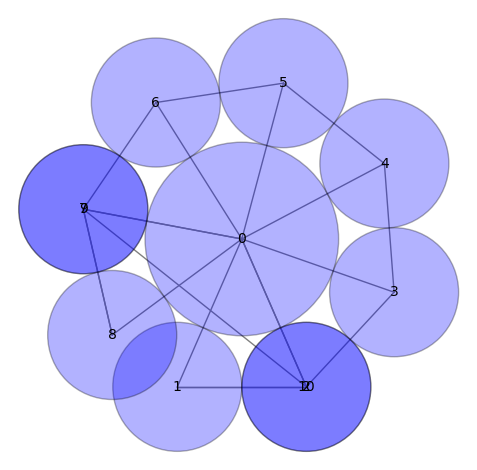

In [2]:

n_rim = 10
G = graphs.WheelGraph(n_rim + 1) # +1 for the center hub

# Define Radii (simple case: all radii = 1)
# You can vary these to see different packing shapes
radii = {v: 1.0 for v in G.vertices()}
# Make the center circle larger just to test geometry
radii[0] = 1.5 

# Run the Algorithm
pos = circle_packing_layout(G, radii)

# --- Visualization ---
P = Graphics()

# Draw edges (mesh structure)
for u, v in G.edges(labels=False):
    if u in pos and v in pos:
        P += line([pos[u], pos[v]], color='gray', zorder=0)

# Draw circles
for v, (x, y) in pos.items():
    r = radii[v]
    # Circle(center, radius)
    P += circle((x, y), r, fill=True, alpha=0.3, edgecolor='black', zorder=1)
    P += text(str(v), (x, y), color='black', zorder=2)

P.show(aspect_ratio=1, axes=False)

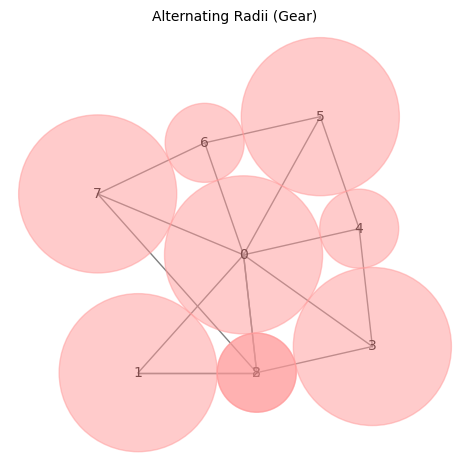

In [6]:
# --- Example 2: Alternating "Gear" Pattern ---
n_rim = 8
G = graphs.WheelGraph(n_rim + 1)

radii = {}
radii[0] = 1.2 # Center

# Set alternating sizes for the rim
# Nodes 1..8 are the rim
for v in range(1, n_rim + 1):
    if v % 2 == 0:
        radii[v] = 0.6  # Small circle
    else:
        radii[v] = 1.2  # Large circle

pos = circle_packing_layout(G, radii)

# Visualization
P = Graphics()
for u, v in G.edges(labels=False):
    if u in pos and v in pos:
        P += line([pos[u], pos[v]], color='gray')

for v, (x, y) in pos.items():
    P += circle((x, y), radii[v], fill=True, color='#ff9999', alpha=0.5, edgecolor='black')
    P += text(str(v), (x, y), color='black')

P.show(aspect_ratio=1, axes=False, title="Alternating Radii (Gear)")

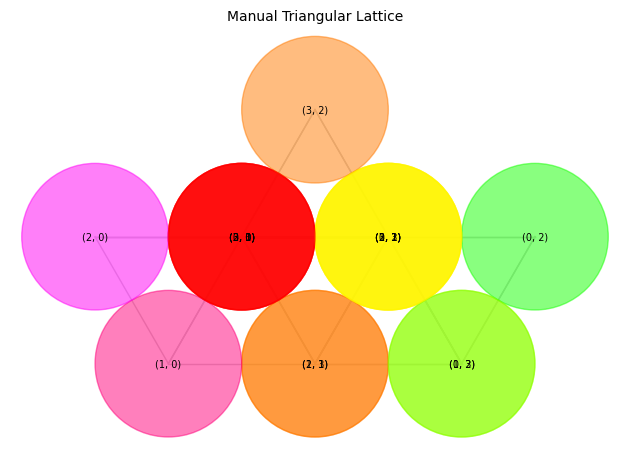

In [10]:
# --- Helper to build Triangular Lattice Manually ---
def make_triangular_lattice(rows, cols):
    G = Graph()
    # 1. Create Grid Nodes
    for r in range(rows):
        for c in range(cols):
            G.add_vertex((r, c))
            
    # 2. Add Edges (Horizontal, Vertical, Diagonal)
    for r in range(rows):
        for c in range(cols):
            # Horizontal neighbor
            if c + 1 < cols: 
                G.add_edge((r, c), (r, c + 1))
            # Vertical neighbor
            if r + 1 < rows: 
                G.add_edge((r, c), (r + 1, c))
            # Diagonal neighbor (this makes it a triangulation)
            if r + 1 < rows and c + 1 < cols: 
                G.add_edge((r, c), (r + 1, c + 1))
    return G

# --- Run Example 3 ---
# Create a 4x4 triangular grid
G = make_triangular_lattice(4, 4)

# Define Radii
# You can use a tuple (r,c) as a key in the dictionary
radii = {v: 0.8 for v in G.vertices()}

# Run Algorithm
pos = circle_packing_layout(G, radii)

# Visualization
P = Graphics()
for u, v in G.edges(labels=False):
    if u in pos and v in pos:
        P += line([pos[u], pos[v]], color='lightgray', zorder=0)

for v, (x, y) in pos.items():
    # Color gradient based on x-position
    P += circle((x, y), radii[v], fill=True, hue=x/10, alpha=0.5, edgecolor='black', zorder=1)
    # Label with the grid coordinate
    P += text(str(v), (x, y), color='black', fontsize=7, zorder=2)

P.show(aspect_ratio=1, axes=False, title="Manual Triangular Lattice")

Function loaded. Running examples...
Refining radii for 1 nodes...


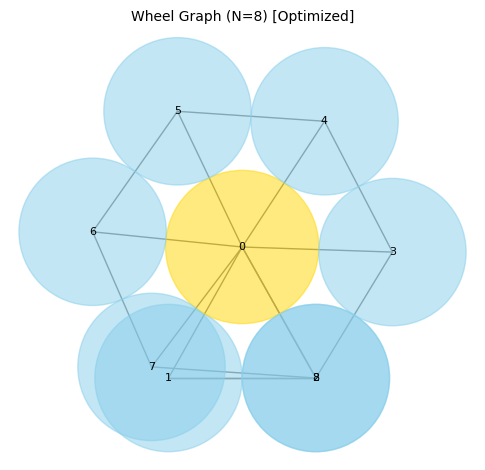

Refining radii for 9 nodes...


/tmp/ipykernel_31197/1595630700.py:44: RuntimeWarning: invalid value encountered in scalar divide
  val = (d_vu**Integer(2) + d_vw**Integer(2) - d_uw**Integer(2)) / (Integer(2) * d_vu * d_vw)


/tmp/ipykernel_31197/1595630700.py:23: RuntimeWarning: invalid value encountered in scalar divide
  val = (d12**Integer(2) + d13**Integer(2) - d23**Integer(2)) / (Integer(2) * d12 * d13)


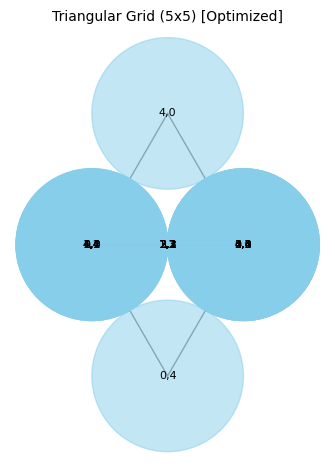

In [ ]:
import numpy as np

# --- 1. CORE GEOMETRY FUNCTIONS ---

def solve_intersection(p1, r1, p2, r2, r3):
    """
    Calculates the position of a new circle (radius r3) tangent to two 
    existing circles (p1, r1) and (p2, r2) using the Law of Cosines.
    """
    z1 = complex(p1[0], p1[1])
    z2 = complex(p2[0], p2[1])
    
    d12 = abs(z2 - z1)      
    d13 = r1 + r3           
    d23 = r2 + r3           
    
    # Safety check for triangle inequality
    if d12 > d13 + d23 or d13 > d12 + d23 or d23 > d12 + d13:
        # If geometry is impossible, return a default position (fails gracefully)
        return (p1[0] + r1 + r3, p1[1])

    # Law of Cosines
    val = (d12**2 + d13**2 - d23**2) / (2 * d12 * d13)
    val = max(-1, min(1, val)) # Clamp for numerical stability
    theta = np.arccos(val)
    
    angle_u_to_w = np.angle(z2 - z1)
    angle_v = angle_u_to_w + theta 
    
    zv = z1 + d13 * np.exp(1j * angle_v)
    return (zv.real, zv.imag)

def get_angle_sum(G, radii, v):
    """Computes total angle surrounding vertex v."""
    angle_sum = 0.0
    neighbors = list(G.neighbors(v))
    for i in range(len(neighbors)):
        u = neighbors[i]
        w = neighbors[(i + 1) % len(neighbors)]
        if G.has_edge(u, w):
            d_vu = radii[v] + radii[u]
            d_vw = radii[v] + radii[w]
            d_uw = radii[u] + radii[w]
            val = (d_vu**2 + d_vw**2 - d_uw**2) / (2 * d_vu * d_vw)
            val = max(-1, min(1, val))
            angle_sum += np.arccos(val)
    return angle_sum

# --- 2. MAIN ALGORITHMS (RELAXATION & LAYOUT) ---

def thurston_relaxation(G, radii, internal_nodes, tolerance=1e-6, max_iter=500):
    """
    Iteratively adjusts radii to ensure the circle packing 'closes up' (sum of angles = 2pi).
    """
    r_current = radii.copy()
    print(f"Refining radii for {len(internal_nodes)} nodes...")
    
    for k in range(max_iter):
        max_err = 0
        for v in internal_nodes:
            angle_sum = get_angle_sum(G, r_current, v)
            error = 2 * np.pi - angle_sum
            max_err = max(max_err, abs(error))
            
            # Update radius: scale by exponential of error
            # If angle sum is too small (gap), we shrink the radius.
            r_current[v] *= np.exp(-0.5 * error) 
            
        if max_err < tolerance:
            print(f"  Converged in {k} iterations (Error: {max_err:.2e})")
            return r_current
            
    print("  Warning: Max iterations reached.")
    return r_current

def compute_layout(G, radii):
    """
    Breadth-First-Search style placement of circles.
    """
    positions = {}
    placed = set()
    nodes = list(G.vertices())
    
    # Initialize first two
    u = nodes[0]
    positions[u] = (0, 0)
    placed.add(u)
    
    neighbors = G.neighbors(u)
    if not neighbors: return positions
    
    w = neighbors[0]
    positions[w] = (radii[u] + radii[w], 0)
    placed.add(w)
    
    L = [n for n in nodes if n not in placed]
    
    while L:
        progress = False
        for v in list(L):
            ns = set(G.neighbors(v))
            placed_ns = list(ns.intersection(placed))
            
            # Try to find two placed neighbors that are connected
            found = False
            for i in range(len(placed_ns)):
                for j in range(i+1, len(placed_ns)):
                    p1, p2 = placed_ns[i], placed_ns[j]
                    if G.has_edge(p1, p2):
                        pos = solve_intersection(positions[p1], radii[p1],
                                                 positions[p2], radii[p2],
                                                 radii[v])
                        positions[v] = pos
                        placed.add(v)
                        L.remove(v)
                        found = True
                        progress = True
                        break
                if found: break
        
        if not progress and L:
            print(f"  Layout stopped early. Unreachable nodes: {len(L)}")
            break
            
    return positions

# --- 3. GRAPH GENERATORS (MANUAL) ---

def make_triangular_grid(rows, cols):
    """Creates a triangular lattice manually to avoid version errors."""
    G = Graph()
    for r in range(rows):
        for c in range(cols):
            G.add_vertex((r,c))
            if c+1 < cols: G.add_edge((r,c), (r,c+1))
            if r+1 < rows: G.add_edge((r,c), (r+1,c))
            if r+1 < rows and c+1 < cols: G.add_edge((r,c), (r+1,c+1))
    return G

# --- 4. MASTER FUNCTION ---

def visualize_packing(type="wheel", size=6, optimize=True):
    """
    Main function to generate, solve, and plot circle packings.
    
    Args:
        type (str): "wheel" or "grid"
        size (int): Number of rim nodes (if wheel) or rows/cols (if grid)
        optimize (bool): If True, runs Thurston Relaxation to close gaps.
    """
    # A. Generate Graph
    if type == "wheel":
        G = graphs.WheelGraph(size + 1)
        internal_nodes = [0] # Only the center
        label = f"Wheel Graph (N={size})"
    elif type == "grid":
        G = make_triangular_grid(size, size)
        # For grid, internal nodes are those not on the boundary
        # Simple heuristic: treat all as internal for now or pick specific ones
        internal_nodes = [v for v in G.vertices() if 0 < v[0] < size-1 and 0 < v[1] < size-1]
        label = f"Triangular Grid ({size}x{size})"
    else:
        print("Unknown type. Using default Wheel.")
        G = graphs.WheelGraph(7)
        internal_nodes = [0]
        label = "Default Wheel"

    # B. Initial Radii
    radii = {v: 1.0 for v in G.vertices()}
    if type == "wheel": radii[0] = 1.0 # Start equal

    # C. Optimization (Thurston)
    if optimize:
        radii = thurston_relaxation(G, radii, internal_nodes)
    
    # D. Layout
    pos = compute_layout(G, radii)
    
    # E. Plotting
    P = Graphics()
    # Edges
    for u, v in G.edges(labels=False):
        if u in pos and v in pos:
            P += line([pos[u], pos[v]], color='gray', zorder=0)
    
    # Circles
    for v, (x, y) in pos.items():
        # Color logic
        if v in internal_nodes: col = 'gold'
        else: col = 'skyblue'
        
        P += circle((x, y), radii[v], fill=True, color=col, alpha=0.5, edgecolor='black', zorder=1)
        
        # Labels (simplify tuple labels for grid)
        txt = str(v) if isinstance(v, (int, str)) else f"{v[0]},{v[1]}"
        P += text(txt, (x, y), color='black', fontsize=8, zorder=2)
        
    P.show(aspect_ratio=1, axes=False, title=label + (" [Optimized]" if optimize else " [Raw]"))

# --- EXAMPLES OF HOW TO CALL IT ---
print("Function loaded. Running examples...")

# 1. A classic Wheel with 8 rim circles (Optimized)
visualize_packing(type="wheel", size=8, optimize=True)

# 2. A 5x5 Triangular Grid (Optimized)
visualize_packing(type="grid", size=5, optimize=True)

Refining radii for 1 nodes...


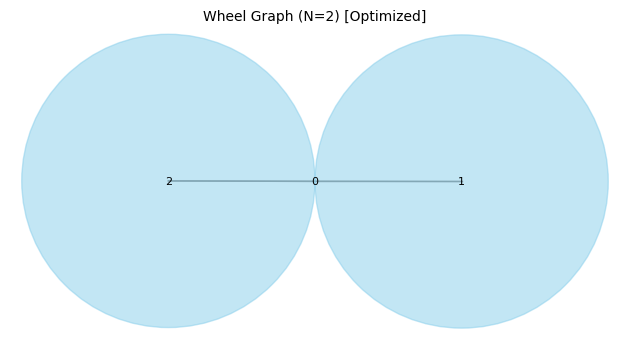

In [20]:
visualize_packing(type="wheel", size=2, optimize=True)

In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import patches

def get_angle_sum(G, radii, v):
    """
    Calculates the sum of angles surrounding vertex v.
    """
    angle_sum = 0.0
    # Find sequence of neighbors forming the 'flower' around v
    # For a proper triangulation, neighbors form a cycle.
    neighbors = list(G.neighbors(v))
    
    # We iterate through adjacent pairs of neighbors
    for i in range(len(neighbors)):
        u = neighbors[i]
        w = neighbors[(i + 1) % len(neighbors)] # Wrap around
        
        # Only calculate if u, w are connected (forming a triangle face)
        if G.has_edge(u, w):
            d_vu = radii[v] + radii[u]
            d_vw = radii[v] + radii[w]
            d_uw = radii[u] + radii[w]
            
            # Law of Cosines for the angle at v
            val = (d_vu**2 + d_vw**2 - d_uw**2) / (2 * d_vu * d_vw)
            val = max(-1, min(1, val)) # Clamp for numerical stability
            angle_sum += np.arccos(val)
            
    return angle_sum

def thurston_relaxation(G, fixed_radii, internal_nodes, tolerance=1e-6, max_iter=1000):
    """
    Iteratively adjusts radii of internal_nodes to target angle sum of 2*pi.
    This is a discrete version of Newton's Method or Gradient Descent.
    """
    radii = fixed_radii.copy()
    
    print(f"Starting Relaxation on {len(internal_nodes)} nodes...")
    
    for i in range(max_iter):
        max_error = 0
        for v in internal_nodes:
            current_sum = get_angle_sum(G, radii, v)
            error = 2 * np.pi - current_sum
            max_error = max(max_error, abs(error))
            
            # Update Rule (Linear approximation):
            # If sum < 2pi, we have a gap -> Shrink radius v (to widen angles)
            # If sum > 2pi, we have overlap -> Grow radius v (to narrow angles)
            # Note: The relationship is inverse! Smaller center r = Larger angles.
            
            # Simple proportional update (learning rate beta)
            beta = 0.5 
            # We use exp(beta * error) to scale the radius
            radii[v] = radii[v] * np.exp(-beta * error)
            
        if max_error < tolerance:
            print(f"Converged in {i} iterations! Max error: {max_error:.2e}")
            break
    else:
        print("Did not fully converge. Try more iterations.")
        
    return radii

# --- 1. SETUP GRAPH ---
n_rim = 5  # Try changing this to 5, 6, 7, etc.
G = nx.wheel_graph(n_rim + 1) # Node 0 is center, 1..n are rim

# Initial Guess: All radii = 1.0
radii_guess = {n: 1.0 for n in G.nodes()}

# We only relax the center node (Node 0) for a Wheel Graph
# The boundary nodes (rim) stay fixed at 1.0
internal_nodes = [0] 

# --- 2. RUN OPTIMIZATION (Thurston's Algorithm) ---
magic_radii = thurston_relaxation(G, radii_guess, internal_nodes)

print(f"Magic Radius for Center: {magic_radii[0]:.4f}")
print(f"Radius for Rim nodes: {magic_radii[1]:.4f}")

# --- 3. RUN LAYOUT (Using Magic Radii) ---
pos = circle_packing_layout(G, magic_radii)

# --- 4. VISUALIZE ---
fig, ax = plt.subplots(figsize=(6, 6))

# Draw Edges
for u, v in G.edges():
    if u in pos and v in pos:
        x_vals = [pos[u][0], pos[v][0]]
        y_vals = [pos[u][1], pos[v][1]]
        ax.plot(x_vals, y_vals, color='gray', lw=1, zorder=1)

# Draw Circles
for n, (x, y) in pos.items():
    r = magic_radii[n]
    # Color center differently
    color = 'gold' if n == 0 else 'skyblue'
    circle = patches.Circle((x, y), r, alpha=0.6, ec='black', fc=color, zorder=2)
    ax.add_patch(circle)
    ax.text(x, y, str(n), ha='center', va='center', fontsize=9, zorder=3)

ax.set_aspect('equal')
ax.autoscale_view()
plt.title(f"Gapless Packing (Center Radius Optimized)")
plt.axis('off')
plt.show()

Starting Relaxation on 1 nodes...
Converged in 20 iterations! Max error: 8.76e-07
Magic Radius for Center: 0.7013
Radius for Rim nodes: 1.0000


AttributeError: 'Graph' object has no attribute 'vertices'